In [19]:
# Importlar
import os
import time
import tempfile
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score

warnings.filterwarnings("ignore")

# Tekrarlanabilirlik
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
print("Importlar tamamlandi.")

Importlar tamamlandi.


In [20]:
# --- KONFIGURASYON (EfficientNetV2) ---
MODEL_NAME = 'tf_efficientnetv2_m'
EXPERIMENT_NAME = "EfficientNetV2_Medium_Baseline_MediumLarge_Run1"

# Hiperparametreler (best no-aug kosuya geri donus)
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1.5e-4
NUM_CLASSES = 8
DROPOUT_RATE = 0.3
DROP_PATH_RATE = 0.15
INPUT_SIZE = 224

# Two-stage fine-tune (best kosuda kapali)
HEAD_ONLY_EPOCHS = 0
HEAD_LEARNING_RATE = 5e-4
STAGE2_UNFREEZE_LAST_N_BLOCKS = 2

# Kriter ayarlari (best no-aug: CE + LS=0.10)
USE_FOCAL_LOSS = False
FOCAL_GAMMA = 1.5

# Hiz / egitim davranisi
USE_AMP = True
LOG_EVERY_N_STEPS = 10

# Duzenlilestirme ve egitim kararliligi
WEIGHT_DECAY = 1e-3
LABEL_SMOOTHING = 0.10
WARMUP_EPOCHS = 4
EARLY_STOPPING_PATIENCE = 7
EARLY_STOPPING_METRIC = 'val_macro_f1'
USE_CLASS_WEIGHTED_LOSS = False
IMBALANCE_RATIO_THRESHOLD = 1.5
FORCE_WEIGHTED_SAMPLER = False

# EMA (best kosuda kapali)
USE_EMA = False
EMA_DECAY = 0.9995
EMA_UPDATE_EVERY = 8

# Windows'ta OneDrive/I/O yavasligina karsi veri yuklemeyi biraz artir.
NUM_WORKERS = 2 if os.name == 'nt' else 4

# Proje kok yolunu calisma dizininden bagimsiz bul
cwd = os.getcwd()
if os.path.isdir(os.path.join(cwd, "data", "prepared-data")):
    PROJECT_ROOT = cwd
elif os.path.isdir(os.path.join(cwd, "..", "data", "prepared-data")):
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, ".."))
else:
    PROJECT_ROOT = cwd

DATA_DIR = os.path.join(PROJECT_ROOT, "data", "prepared-data")

dropout_tag = f"dropout{int(round(DROPOUT_RATE * 10)):02d}"
ls_tag = f"ls{int(round(LABEL_SMOOTHING * 100)):02d}"
wd_tag = f"wd{str(WEIGHT_DECAY).replace('.', 'p').replace('-', 'm')}"
lr_tag = f"lr{LEARNING_RATE:g}".replace(".", "p")
aug_tag = "augOFF"
sampler_tag = "smpON" if FORCE_WEIGHTED_SAMPLER else "smpOFF"
RUN_TAG = f"{dropout_tag}_{ls_tag}_{wd_tag}_bs{BATCH_SIZE}_ep{EPOCHS}_{lr_tag}_{aug_tag}_{sampler_tag}"
RUN_NAME = f"{EXPERIMENT_NAME}_{RUN_TAG}"

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "models", "pytorch", RUN_NAME)
os.makedirs(OUTPUT_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, f"best_model_{MODEL_NAME}_{RUN_TAG}.pth")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CWD: {cwd}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Cihaz: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"Model: {MODEL_NAME}")
print(f"Run Tag: {RUN_TAG}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"Kayit Yeri: {OUTPUT_DIR}")
print(f"Best Model Yolu: {BEST_MODEL_PATH}")
print(f"NUM_WORKERS: {NUM_WORKERS}")
print(f"USE_AMP: {USE_AMP}")
print(f"INPUT_SIZE: {INPUT_SIZE}")
print(f"USE_FOCAL_LOSS: {USE_FOCAL_LOSS}, FOCAL_GAMMA: {FOCAL_GAMMA}")
print(f"EARLY_STOPPING_METRIC: {EARLY_STOPPING_METRIC}")
print(f"USE_EMA: {USE_EMA}, EMA_DECAY: {EMA_DECAY}, EMA_UPDATE_EVERY: {EMA_UPDATE_EVERY}")
print(f"HEAD_ONLY_EPOCHS: {HEAD_ONLY_EPOCHS}, HEAD_LEARNING_RATE: {HEAD_LEARNING_RATE}")
print(f"STAGE2_UNFREEZE_LAST_N_BLOCKS: {STAGE2_UNFREEZE_LAST_N_BLOCKS}")
print(f"LOG_EVERY_N_STEPS: {LOG_EVERY_N_STEPS}")

CWD: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\EfficienNetV2
PROJECT_ROOT: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison
Cihaz: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Model: tf_efficientnetv2_s
Run Tag: dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF
DATA_DIR: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\data\prepared-data
Kayit Yeri: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\EfficientNetV2_S_Baseline_NoAug_BestLike_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF
Best Model Yolu: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\EfficientNetV2_S_Baseline_NoAug_BestLike_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF\best_model_tf_efficientnetv2_s_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF.pth
NUM_WORKERS: 2
USE_AMP: True
INPUT_SIZE: 224
USE_FOCAL_LOSS: False, FOCAL_GAMMA: 1.5
EARLY_STOPPING_METRIC: val_macro_f1


In [21]:
# ImageNet Normalize Degerleri
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

# Veri Donusumleri (augmentation kapali)
train_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

eval_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

data_transforms = {
    'train': train_transform,
    'val': eval_transform,
    'test': eval_transform
}

image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}

# Sinif dengesizligi analizi
train_targets = np.array(image_datasets['train'].targets)
class_sample_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
imbalance_ratio = class_sample_counts.max() / max(1, class_sample_counts.min())
AUTO_USE_WEIGHTED_SAMPLER = imbalance_ratio >= IMBALANCE_RATIO_THRESHOLD
USE_WEIGHTED_SAMPLER = FORCE_WEIGHTED_SAMPLER or AUTO_USE_WEIGHTED_SAMPLER

class_weight_values = class_sample_counts.sum() / (NUM_CLASSES * np.clip(class_sample_counts, 1, None))
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weight_values, dtype=torch.float32)

train_sampler = None
if USE_WEIGHTED_SAMPLER:
    sample_weights = class_weight_values[train_targets]
    train_sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

loader_common_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': (DEVICE == 'cuda')
}
if NUM_WORKERS > 0:
    loader_common_kwargs['persistent_workers'] = True
    loader_common_kwargs['prefetch_factor'] = 2

dataloaders = {
    'train': DataLoader(
        image_datasets['train'],
        batch_size=BATCH_SIZE,
        shuffle=(train_sampler is None),
        sampler=train_sampler,
        **loader_common_kwargs
    ),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, **loader_common_kwargs),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, **loader_common_kwargs)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

train_files = set(os.path.basename(p).lower() for p, _ in image_datasets['train'].samples)
val_files = set(os.path.basename(p).lower() for p, _ in image_datasets['val'].samples)
test_files = set(os.path.basename(p).lower() for p, _ in image_datasets['test'].samples)
overlap_train_val = train_files.intersection(val_files)
overlap_train_test = train_files.intersection(test_files)

os.makedirs(OUTPUT_DIR, exist_ok=True)
primary_leak_report_path = os.path.join(OUTPUT_DIR, f"leakage_check_{RUN_TAG}.txt")
fallback_leak_dir = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'reports')
fallback_leak_report_path = os.path.join(fallback_leak_dir, f"leakage_check_{RUN_TAG}.txt")

leak_report_path = primary_leak_report_path
try:
    with open(leak_report_path, "w", encoding="utf-8") as f:
        f.write(f"Train-Val same filename count: {len(overlap_train_val)}\n")
        f.write(f"Train-Test same filename count: {len(overlap_train_test)}\n")
except (FileNotFoundError, OSError):
    os.makedirs(fallback_leak_dir, exist_ok=True)
    leak_report_path = fallback_leak_report_path
    with open(leak_report_path, "w", encoding="utf-8") as f:
        f.write(f"Train-Val same filename count: {len(overlap_train_val)}\n")
        f.write(f"Train-Test same filename count: {len(overlap_train_test)}\n")
    print("Uyari: Uzun yol nedeniyle leakage raporu fallback klasorune kaydedildi.")

print(f"Siniflar: {class_names}")
print(f"Egitim Verisi: {dataset_sizes['train']}")
print(f"Validasyon Verisi: {dataset_sizes['val']}")
print(f"Test Verisi: {dataset_sizes['test']}")
print(f"Sinif sayimlari (train): {class_sample_counts.tolist()}")
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")
print(f"Augmentation: Kapali")
print(f"Weighted sampler aktif: {USE_WEIGHTED_SAMPLER}")
print(f"Class-weighted loss aktif: {USE_CLASS_WEIGHTED_LOSS}")
print(f"Leakage raporu: {leak_report_path}")

Siniflar: ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
Egitim Verisi: 5592
Validasyon Verisi: 1200
Test Verisi: 1208
Sinif sayimlari (train): [699, 699, 699, 699, 699, 699, 699, 699]
Imbalance ratio (max/min): 1.00
Augmentation: Kapali
Weighted sampler aktif: False
Class-weighted loss aktif: False
Leakage raporu: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\EfficientNetV2_S_Baseline_NoAug_BestLike_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF\leakage_check_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF.txt


In [22]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()

def create_model():
    print(f"Model indiriliyor: {MODEL_NAME}...")
    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=NUM_CLASSES,
        drop_rate=DROPOUT_RATE,
        drop_path_rate=DROP_PATH_RATE
    )
    return model

def set_finetune_mode(model, mode='full', unfreeze_last_n_blocks=2):
    for param in model.parameters():
        param.requires_grad = False

    # Head her zaman acik kalmali.
    head_attr_candidates = ["classifier", "fc", "head"]
    for attr in head_attr_candidates:
        module = getattr(model, attr, None)
        if module is not None:
            for param in module.parameters():
                param.requires_grad = True

    if mode == 'full':
        for param in model.parameters():
            param.requires_grad = True
    elif mode == 'last_n_blocks':
        blocks = getattr(model, 'blocks', None)
        if blocks is not None and len(blocks) > 0:
            n = max(1, min(int(unfreeze_last_n_blocks), len(blocks)))
            for idx in range(len(blocks) - n, len(blocks)):
                for param in blocks[idx].parameters():
                    param.requires_grad = True
            conv_head = getattr(model, 'conv_head', None)
            bn2 = getattr(model, 'bn2', None)
            if conv_head is not None:
                for param in conv_head.parameters():
                    param.requires_grad = True
            if bn2 is not None:
                for param in bn2.parameters():
                    param.requires_grad = True
        else:
            # blocks ozelligi olmayan mimarilerde stage-2'yi tum model fine-tune'a dusur.
            for param in model.parameters():
                param.requires_grad = True

def build_optimizer_and_scheduler(model, learning_rate, stage_epochs):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(trainable_params, lr=learning_rate, weight_decay=WEIGHT_DECAY)

    warmup_epochs = min(WARMUP_EPOCHS, max(1, stage_epochs // 2))

    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(max(1, warmup_epochs))
        progress = (epoch - warmup_epochs) / float(max(1, stage_epochs - warmup_epochs))
        progress = min(max(progress, 0.0), 1.0)
        return 0.5 * (1.0 + np.cos(np.pi * progress))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
    return optimizer, scheduler

model = create_model()
model = model.to(DEVICE)

loss_weight = CLASS_WEIGHTS_TENSOR.to(DEVICE) if USE_CLASS_WEIGHTED_LOSS else None
if USE_FOCAL_LOSS:
    criterion = FocalLoss(gamma=FOCAL_GAMMA, weight=loss_weight)
else:
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING, weight=loss_weight)

set_finetune_mode(model, mode='full', unfreeze_last_n_blocks=STAGE2_UNFREEZE_LAST_N_BLOCKS)
optimizer, scheduler = build_optimizer_and_scheduler(model, LEARNING_RATE, max(1, EPOCHS))
print("Model GPU'ya yuklendi ve egitime hazir.")
print(f"AdamW + weight_decay={WEIGHT_DECAY}, label_smoothing={LABEL_SMOOTHING}, drop_path_rate={DROP_PATH_RATE}")
print(f"Kayıp fonksiyonu: {'FocalLoss' if USE_FOCAL_LOSS else 'CrossEntropyLoss'}")

Model indiriliyor: tf_efficientnetv2_s...


Model GPU'ya yuklendi ve egitime hazir.
AdamW + weight_decay=0.001, label_smoothing=0.1, drop_path_rate=0.15
Kayıp fonksiyonu: CrossEntropyLoss


In [23]:
TRAIN_MODEL_VERSION = "v7_macrof1_ema_two_stage_fast"

def _clone_state_dict(state_dict):
    return {k: v.detach().clone() for k, v in state_dict.items()}

def _update_ema_state(model, ema_state, decay):
    with torch.no_grad():
        current = model.state_dict()
        for k, v in current.items():
            if not torch.is_floating_point(v):
                ema_state[k] = v.detach().clone()
            else:
                ema_state[k].mul_(decay).add_(v.detach(), alpha=(1.0 - decay))

def train_model(model, criterion, optimizer, scheduler, num_epochs):
    required_globals = [
        "dataloaders", "dataset_sizes", "OUTPUT_DIR", "DEVICE", "BEST_MODEL_PATH", "EARLY_STOPPING_PATIENCE",
        "HEAD_ONLY_EPOCHS", "HEAD_LEARNING_RATE", "LEARNING_RATE", "USE_EMA", "EMA_DECAY",
        "EMA_UPDATE_EVERY", "STAGE2_UNFREEZE_LAST_N_BLOCKS"
    ]
    missing = [name for name in required_globals if name not in globals()]
    if missing:
        raise RuntimeError(
            f"Eksik degisken(ler): {missing}. Lutfen once veri ve konfigurasyon hucrelerini calistirin."
        )

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(os.path.dirname(BEST_MODEL_PATH), exist_ok=True)

    # Windows + non-ASCII + uzun path durumlari icin kisa ve guvenli checkpoint yollarini dene.
    def _candidate_checkpoint_paths():
        candidates = [BEST_MODEL_PATH]

        short_tag = f"{abs(hash(RUN_TAG)) % 10**10:010d}"
        temp_root = tempfile.gettempdir()
        short_temp_dir = os.path.join(temp_root, "gcm")
        os.makedirs(short_temp_dir, exist_ok=True)
        candidates.append(os.path.join(short_temp_dir, f"ckpt_{short_tag}.pth"))

        very_short_dir = r"C:\\Temp\\gcm"
        try:
            os.makedirs(very_short_dir, exist_ok=True)
            candidates.append(os.path.join(very_short_dir, f"c_{short_tag}.pth"))
        except OSError:
            pass

        uniq = []
        seen = set()
        for p in candidates:
            if p not in seen:
                uniq.append(p)
                seen.add(p)
        return uniq

    checkpoint_path = None
    for candidate in _candidate_checkpoint_paths():
        try:
            os.makedirs(os.path.dirname(candidate), exist_ok=True)
            torch.save(model.state_dict(), candidate)
            checkpoint_path = candidate
            if candidate != BEST_MODEL_PATH:
                print(f"Uyari: Guvenli checkpoint yolu kullaniliyor: {candidate}")
            break
        except Exception:
            continue

    if checkpoint_path is None:
        raise RuntimeError("Checkpoint icin yazilabilir bir dosya yolu bulunamadi.")

    use_amp = bool(globals().get("USE_AMP", False) and DEVICE == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    use_ema = bool(globals().get("USE_EMA", False))
    ema_decay = float(globals().get("EMA_DECAY", 0.9995))
    ema_update_every = max(1, int(globals().get("EMA_UPDATE_EVERY", 8)))
    ema_state = _clone_state_dict(model.state_dict()) if use_ema else None

    head_only_epochs = int(globals().get("HEAD_ONLY_EPOCHS", 0))
    head_only_epochs = max(0, min(head_only_epochs, max(0, num_epochs - 1)))
    use_two_stage = head_only_epochs > 0

    if use_two_stage:
        set_finetune_mode(model, mode='head_only', unfreeze_last_n_blocks=STAGE2_UNFREEZE_LAST_N_BLOCKS)
        optimizer, scheduler = build_optimizer_and_scheduler(model, HEAD_LEARNING_RATE, max(1, head_only_epochs))
        print(f"Asama 1 aktif: sadece head egitimi ({head_only_epochs} epoch, lr={HEAD_LEARNING_RATE})")
    else:
        set_finetune_mode(model, mode='last_n_blocks', unfreeze_last_n_blocks=STAGE2_UNFREEZE_LAST_N_BLOCKS)
        optimizer, scheduler = build_optimizer_and_scheduler(model, LEARNING_RATE, max(1, num_epochs))

    print(f"AMP aktif: {use_amp}")
    print(f"EMA aktif: {use_ema} (decay={ema_decay}, update_every={ema_update_every})")
    print("Early stopping metriği: val_macro_f1")
    print("Log modu: epoch ozet")

    since = time.time()
    best_acc = 0.0
    best_val_loss = float('inf')
    best_val_macro_f1 = -1.0
    epochs_without_improvement = 0
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_macro_f1': [],
        'lr': []
    }
    global_step = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            val_state_backup = None
            if phase == 'val' and use_ema and ema_state is not None:
                val_state_backup = _clone_state_dict(model.state_dict())
                model.load_state_dict(ema_state, strict=True)

            running_loss = 0.0
            running_corrects = 0
            phase_targets = []
            phase_preds = []

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)

                with torch.set_grad_enabled(phase == 'train'):
                    with torch.cuda.amp.autocast(enabled=use_amp):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()
                        global_step += 1
                        if use_ema and ema_state is not None and (global_step % ema_update_every == 0):
                            _update_ema_state(model, ema_state, ema_decay)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                if phase == 'val':
                    phase_targets.extend(labels.detach().cpu().numpy())
                    phase_preds.extend(preds.detach().cpu().numpy())

            if phase == 'val' and val_state_backup is not None:
                model.load_state_dict(val_state_backup, strict=True)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'train':
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            else:
                epoch_macro_f1 = f1_score(phase_targets, phase_preds, average='macro')
                history['val_macro_f1'].append(float(epoch_macro_f1))
                print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Macro-F1: {epoch_macro_f1:.4f}")

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss

                if epoch_macro_f1 > best_val_macro_f1 + 1e-6:
                    best_val_macro_f1 = float(epoch_macro_f1)
                    epochs_without_improvement = 0

                    state_to_save = ema_state if (use_ema and ema_state is not None) else model.state_dict()
                    saved = False
                    for candidate in _candidate_checkpoint_paths():
                        try:
                            os.makedirs(os.path.dirname(candidate), exist_ok=True)
                            torch.save(state_to_save, candidate)
                            checkpoint_path = candidate
                            saved = True
                            break
                        except Exception:
                            continue

                    if not saved:
                        raise RuntimeError("En iyi modeli kaydetmek icin yazilabilir bir yol bulunamadi.")

                    print(f"En Iyi Model (val_macro_f1: {best_val_macro_f1:.4f}) -> {checkpoint_path}")
                else:
                    epochs_without_improvement += 1
                    print(f"Val macro-F1 iyilesmedi: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}")

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        print(f"Guncel LR: {current_lr:.8f}")

        # Head-only asama bitince son bloklar + head ile fine-tune et.
        if use_two_stage and (epoch + 1) == head_only_epochs:
            remaining_epochs = max(1, num_epochs - head_only_epochs)
            set_finetune_mode(model, mode='last_n_blocks', unfreeze_last_n_blocks=STAGE2_UNFREEZE_LAST_N_BLOCKS)
            optimizer, scheduler = build_optimizer_and_scheduler(model, LEARNING_RATE, remaining_epochs)
            print(
                f"Asama 2 aktif: son {STAGE2_UNFREEZE_LAST_N_BLOCKS} blok + head fine-tune "
                f"(kalan epoch={remaining_epochs}, lr={LEARNING_RATE})"
            )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Erken durdurma tetiklendi (val_macro_f1).")
            break

    if use_ema and ema_state is not None and (global_step % ema_update_every != 0):
        _update_ema_state(model, ema_state, ema_decay)

    time_elapsed = time.time() - since
    print(f'\nEgitim Tamamlandi: {time_elapsed // 60:.0f}dk {time_elapsed % 60:.0f}sn')
    print(f'En Iyi Validasyon Dogrulugu: {best_acc:.4f}')
    print(f'En Dusuk Validasyon Kaybi: {best_val_loss:.4f}')
    print(f'En Iyi Val Macro-F1: {best_val_macro_f1:.4f}')

    model.load_state_dict(torch.load(checkpoint_path))
    globals()['EMA_STATE_DICT'] = _clone_state_dict(model.state_dict()) if use_ema else None
    return model, history

In [24]:
# --- BASLAT ---
required_vars = ["model", "criterion", "optimizer", "scheduler", "train_model"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        f"Eksik degisken(ler): {missing}. Lutfen once model/egitim hazirlik hucrelerini calistirin."
    )

if globals().get("TRAIN_MODEL_VERSION") != "v7_macrof1_ema_two_stage_fast":
    raise RuntimeError(
        "Egitim fonksiyonu guncel degil. Lutfen 5. hucreyi yeniden calistirip tekrar deneyin."
    )

num_epochs = int(globals().get("EPOCHS", 50))
model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=num_epochs)

Uyari: Guvenli checkpoint yolu kullaniliyor: C:\Users\mehme\AppData\Local\Temp\gcm\ckpt_9453056581.pth
AMP aktif: True
EMA aktif: False (decay=0.9995, update_every=8)
Early stopping metriği: val_macro_f1
Log modu: epoch ozet
Epoch 1/50
----------


KeyboardInterrupt: 

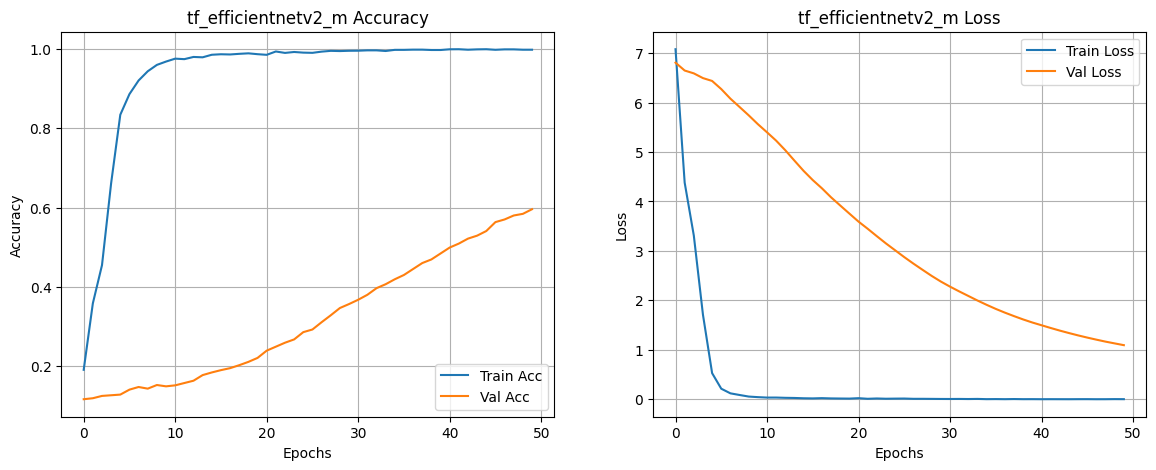

Grafikler kaydedildi: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\outputs\tf_efficientnetv2_m\plots\training_graph_tf_efficientnetv2_m_dropout03_ls05_wd0p001_bs32_ep50_lr0p00015_img224_focalg1p5_smpOFF_ema0p9995_h3_hlr0p0005_u2.png


In [17]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title(f'{MODEL_NAME} Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title(f'{MODEL_NAME} Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

PLOT_OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'plots')
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
plot_path = os.path.join(PLOT_OUTPUT_DIR, f'training_graph_{MODEL_NAME}_{RUN_TAG}.png')
plt.savefig(plot_path)
plt.show()
print(f"Grafikler kaydedildi: {plot_path}")


TEST SETI DEGERLENDIRMESI
Test degerlendirmesi EMA agirliklari ile yapiliyor.

Siniflandirma Raporu:
                        precision    recall  f1-score   support

    dyed-lifted-polyps     0.4589    0.6291    0.5307       151
dyed-resection-margins     0.7065    0.4305    0.5350       151
           esophagitis     0.7009    0.4967    0.5814       151
          normal-cecum     0.8350    0.5695    0.6772       151
        normal-pylorus     0.7182    0.8609    0.7831       151
         normal-z-line     0.5200    0.8609    0.6484       151
                polyps     0.6639    0.5364    0.5934       151
    ulcerative-colitis     0.6712    0.6490    0.6599       151

              accuracy                         0.6291      1208
             macro avg     0.6593    0.6291    0.6261      1208
          weighted avg     0.6593    0.6291    0.6261      1208

Macro F1: 0.6261
Class recall degerleri:
  dyed-lifted-polyps: 0.6291
  dyed-resection-margins: 0.4305
  esophagitis: 0.4967
  

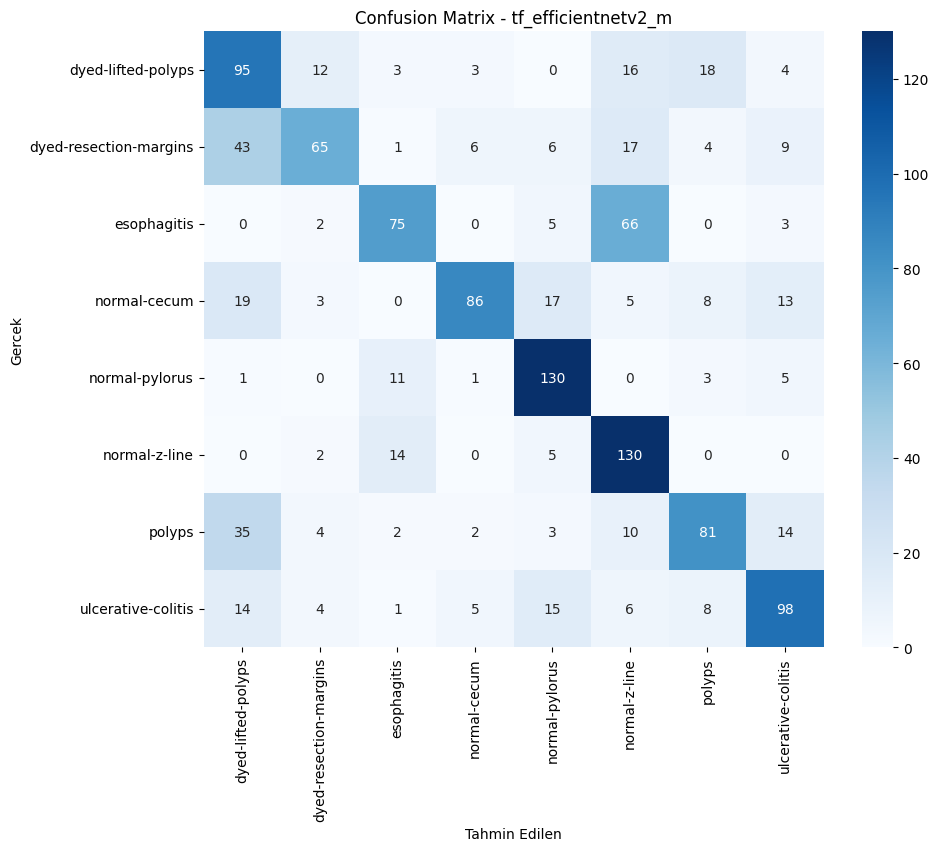

Confusion matrix kaydedildi: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\outputs\tf_efficientnetv2_m\plots\confusion_matrix_tf_efficientnetv2_m_dropout03_ls05_wd0p001_bs32_ep50_lr0p00015_img224_focalg1p5_smpOFF_ema0p9995_h3_hlr0p0005_u2.png
esophagitis <-> normal-z-line toplam hata: 80
dyed-lifted-polyps <-> dyed-resection-margins toplam hata: 55
Ablation sonuclari kaydedildi: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\outputs\tf_efficientnetv2_m\ablation_results_tf_efficientnetv2_m.csv
Son kayit:
                                                                                                                                    run_name                                                                                      run_tag          model_name  batch_size  learning_rate  weight_decay  dropout_rate  label_smoothing  force_weighted_sampler  use_weighted_sampler  use_class_weighted_loss  early_stopping_patience early_stopping_metric  use_ema  

In [18]:
print("\nTEST SETI DEGERLENDIRMESI")

model.eval()
y_true = []
y_pred = []

use_ema_eval = bool(globals().get('USE_EMA', False) and globals().get('EMA_STATE_DICT') is not None)
eval_backup_state = None
if use_ema_eval:
    eval_backup_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(EMA_STATE_DICT, strict=True)
    print("Test degerlendirmesi EMA agirliklari ile yapiliyor.")

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("\nSiniflandirma Raporu:")
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

macro_f1 = f1_score(y_true, y_pred, average='macro')
class_recalls = recall_score(y_true, y_pred, average=None, labels=list(range(len(class_names))))
print(f"Macro F1: {macro_f1:.4f}")
print("Class recall degerleri:")
for class_name, rec in zip(class_names, class_recalls):
    print(f"  {class_name}: {rec:.4f}")

os.makedirs(OUTPUT_DIR, exist_ok=True)
primary_report_path = os.path.join(OUTPUT_DIR, f'classification_report_{MODEL_NAME}_{RUN_TAG}.txt')
fallback_report_dir = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'reports')
fallback_report_path = os.path.join(fallback_report_dir, f'classification_report_{MODEL_NAME}_{RUN_TAG}.txt')

report_path = primary_report_path
try:
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report)
        f.write(f"\nMacro F1: {macro_f1:.6f}\n")
        f.write("Class Recall:\n")
        for class_name, rec in zip(class_names, class_recalls):
            f.write(f"{class_name}: {rec:.6f}\n")
except (FileNotFoundError, OSError):
    os.makedirs(fallback_report_dir, exist_ok=True)
    report_path = fallback_report_path
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report)
        f.write(f"\nMacro F1: {macro_f1:.6f}\n")
        f.write("Class Recall:\n")
        for class_name, rec in zip(class_names, class_recalls):
            f.write(f"{class_name}: {rec:.6f}\n")
    print("Uyari: Uzun yol nedeniyle rapor fallback klasorune kaydedildi.")
print(f"Classification report kaydedildi: {report_path}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gercek')
plt.title(f'Confusion Matrix - {MODEL_NAME}')
PLOT_OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'plots')
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
plot_path = os.path.join(PLOT_OUTPUT_DIR, f'confusion_matrix_{MODEL_NAME}_{RUN_TAG}.png')
plt.savefig(plot_path)
plt.show()
print(f"Confusion matrix kaydedildi: {plot_path}")

name_to_idx = {name: i for i, name in enumerate(class_names)}
pair_1_a = 'esophagitis'
pair_1_b = 'normal-z-line'
pair_2_a = 'dyed-lifted-polyps'
pair_2_b = 'dyed-resection-margins'

pair_1_err = None
pair_2_err = None
if pair_1_a in name_to_idx and pair_1_b in name_to_idx:
    i, j = name_to_idx[pair_1_a], name_to_idx[pair_1_b]
    pair_1_err = int(cm[i, j] + cm[j, i])
if pair_2_a in name_to_idx and pair_2_b in name_to_idx:
    i, j = name_to_idx[pair_2_a], name_to_idx[pair_2_b]
    pair_2_err = int(cm[i, j] + cm[j, i])

if pair_1_err is not None:
    print(f"{pair_1_a} <-> {pair_1_b} toplam hata: {pair_1_err}")
if pair_2_err is not None:
    print(f"{pair_2_a} <-> {pair_2_b} toplam hata: {pair_2_err}")

latest_metrics = {
    'run_name': RUN_NAME,
    'run_tag': RUN_TAG,
    'model_name': MODEL_NAME,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'dropout_rate': DROPOUT_RATE,
    'label_smoothing': LABEL_SMOOTHING,
    'force_weighted_sampler': FORCE_WEIGHTED_SAMPLER,
    'use_weighted_sampler': USE_WEIGHTED_SAMPLER,
    'use_class_weighted_loss': USE_CLASS_WEIGHTED_LOSS,
    'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    'early_stopping_metric': EARLY_STOPPING_METRIC,
    'use_ema': USE_EMA,
    'ema_decay': EMA_DECAY,
    'best_val_acc': float(max(history['val_acc'])) if 'history' in globals() else None,
    'best_val_loss': float(min(history['val_loss'])) if 'history' in globals() else None,
    'best_val_macro_f1': float(max(history['val_macro_f1'])) if 'history' in globals() and 'val_macro_f1' in history else None,
    'test_macro_f1': float(macro_f1),
    'pair_err_esophagitis_normal_z_line': pair_1_err,
    'pair_err_dyed_lifted_vs_resection': pair_2_err
}

ablation_csv_path = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, f'ablation_results_{MODEL_NAME}.csv')
os.makedirs(os.path.dirname(ablation_csv_path), exist_ok=True)

new_row_df = pd.DataFrame([latest_metrics])
if os.path.exists(ablation_csv_path):
    old_df = pd.read_csv(ablation_csv_path)
    if 'run_tag' in old_df.columns:
        old_df = old_df[old_df['run_tag'] != RUN_TAG]
    result_df = pd.concat([old_df, new_row_df], ignore_index=True)
else:
    result_df = new_row_df

result_df.to_csv(ablation_csv_path, index=False)
print(f"Ablation sonuclari kaydedildi: {ablation_csv_path}")
print("Son kayit:")
print(new_row_df.to_string(index=False))

if eval_backup_state is not None:
    model.load_state_dict(eval_backup_state, strict=True)

In [ ]:
# --- ABLATION KARSILASTIRMA OZETI ---
ablation_csv_path = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, f'ablation_results_{MODEL_NAME}.csv')
os.makedirs(os.path.dirname(ablation_csv_path), exist_ok=True)

if not os.path.exists(ablation_csv_path):
    raise FileNotFoundError(f"Ablation CSV bulunamadi: {ablation_csv_path}")

df = pd.read_csv(ablation_csv_path).copy()
if df.empty:
    raise ValueError('Ablation CSV bos.')

numeric_cols = [
    'best_val_acc',
    'best_val_loss',
    'best_val_macro_f1',
    'test_macro_f1',
    'pair_err_esophagitis_normal_z_line',
    'pair_err_dyed_lifted_vs_resection'
 ]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

if 'pair_err_esophagitis_normal_z_line' in df.columns and 'pair_err_dyed_lifted_vs_resection' in df.columns:
    df['critical_pair_error_total'] = (
        df['pair_err_esophagitis_normal_z_line'].fillna(0) +
        df['pair_err_dyed_lifted_vs_resection'].fillna(0)
    )
else:
    df['critical_pair_error_total'] = np.nan

sort_cols = []
ascending = []
if 'test_macro_f1' in df.columns:
    sort_cols.append('test_macro_f1')
    ascending.append(False)
if 'best_val_macro_f1' in df.columns:
    sort_cols.append('best_val_macro_f1')
    ascending.append(False)
if 'critical_pair_error_total' in df.columns:
    sort_cols.append('critical_pair_error_total')
    ascending.append(True)
if 'best_val_loss' in df.columns:
    sort_cols.append('best_val_loss')
    ascending.append(True)

if sort_cols:
    ranked_df = df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)
else:
    ranked_df = df.copy()

display_cols = [
    'run_name', 'run_tag', 'test_macro_f1', 'best_val_macro_f1', 'best_val_acc', 'best_val_loss',
    'pair_err_esophagitis_normal_z_line', 'pair_err_dyed_lifted_vs_resection',
    'critical_pair_error_total', 'use_ema', 'ema_decay', 'force_weighted_sampler', 'learning_rate', 'weight_decay'
 ]
display_cols = [c for c in display_cols if c in ranked_df.columns]

print(f"Toplam kayit: {len(ranked_df)}")
print('\nEn iyi 5 kosu:')
display(ranked_df[display_cols].head(5))

best_run = ranked_df.iloc[0]
print('\nSecilen en iyi kosu:')
for c in display_cols:
    print(f"{c}: {best_run[c]}")

Toplam kayit: 3

En iyi 5 kosu:


,run_name,run_tag,test_macro_f1,best_val_acc,best_val_loss,pair_err_esophagitis_normal_z_line,pair_err_dyed_lifted_vs_resection,critical_pair_error_total,force_weighted_sampler,learning_rate,weight_decay
0,EfficientNetV2_Medium_Baseline_MediumLarge_Run...,dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_aug...,0.943633,0.945000,0.609837,35,12,47,False,0.00015,0.0010
1,EfficientNetV2_Medium_Baseline_MediumLarge_Run...,dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_aug...,0.941988,0.939167,0.627918,38,15,53,False,0.00015,0.0010
2,EfficientNetV2_Medium_Baseline_MediumLarge_Run...,dropout02_ls10_wd0p0005_bs32_ep50_lr0p0002_smpOFF,0.928795,0.938333,0.625509,45,18,63,False,0.00020,0.0005



Secilen en iyi kosu:
run_name: EfficientNetV2_Medium_Baseline_MediumLarge_Run1_dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF
run_tag: dropout03_ls10_wd0p001_bs32_ep50_lr0p00015_augOFF_smpOFF
test_macro_f1: 0.9436334765406706
best_val_acc: 0.945
best_val_loss: 0.6098369495073954
pair_err_esophagitis_normal_z_line: 35
pair_err_dyed_lifted_vs_resection: 12
critical_pair_error_total: 47
force_weighted_sampler: False
learning_rate: 0.00015
weight_decay: 0.001
